# Regresja liniowa

In [ ]:
# --- podstawy ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("../data/processed/epl_features.csv")

In [163]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values(["Date", "HomeTeam", "AwayTeam"]).reset_index(drop=True)
print(df.shape)
df.head(3)

(3420, 114)


,Div,Date,HomeTeam,AwayTeam,Referee,FTHG,FTAG,FTR,HS,AS,...,FormDiff_AttDefRatio_last5,FormDiff_GoalsShare_last5,Home_RecentFormIdx,Away_RecentFormIdx,FormDiff_RecentFormIdx,Market_ImpliedDiff_b365,Market_ImpliedDiff_ps,Market_BigHomeFav,Market_BigAwayFav,Market_BalancedMatch
0,E0,2014-08-16,Arsenal,Crystal Palace,J Moss,2.0,1.0,H,14.0,4.0,...,NaN,NaN,NaN,NaN,NaN,0.718593,0.708064,1,0,0
1,E0,2014-08-16,Leicester,Everton,M Jones,2.0,2.0,D,11.0,13.0,...,NaN,NaN,NaN,NaN,NaN,-0.101796,-0.086236,0,0,0
2,E0,2014-08-16,Manchester United,Swansea,M Dean,1.0,2.0,A,14.0,5.0,...,NaN,NaN,NaN,NaN,NaN,0.627931,0.622914,1,0,0


In [164]:
# cols_to_exclude = {
#     # meta / identyfikatory
#     "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

#     # wynikowe i bieżące statystyki meczu (niedostępne przed meczem)
#     "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
#     "GoalDiff", "TotalGoals",
#     "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
#     "HY", "AY", "HR", "AR",

#     # NOWE — usuwamy nadmiarowe prawdopodobieństwa, które psują regresję
#     "Prob_D_b365", "Prob_A_b365"
# }

In [165]:
target = "FTR"

cols_to_exclude = {
    # meta / identyfikatory
    "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

    # wynik meczu – niedostępne przed spotkaniem
    "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
    "GoalDiff", "TotalGoals",
    "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
    "HY", "AY", "HR", "AR",

    # bukmacher – nadmiarowe prawdopodobieństwa i miary
    "Prob_D_b365", "Prob_A_b365",
    "Prob_H_ps", "Prob_D_ps", "Prob_A_ps",
    "Margin_B365", "Margin_PS",
    "OddsDiff_B365", "OddsDiff_PS",
    "OddsSpread_H", "OddsSpread_D", "OddsSpread_A",

    # forma gospodarzy – duplikaty lub mało stabilne
    "Home_Wins_last5",
    "Home_CleanSheets_last5",
    "Home_Conceded0plus_last5",
    "Home_GD_last3",
    "Home_Pts_last3",
    "Home_GD_last10",         # silna korelacja z Pts_last10
    "Home_AvgGD_season",

    # forma gości – duplikaty lub mało stabilne
    "Away_Wins_last5",
    "Away_CleanSheets_last5",
    "Away_Conceded0plus_last5",
    "Away_GD_last3",
    "Away_Pts_last3",
    "Away_GD_last10",         # silna korelacja z Pts_last10
    "Away_AvgGD_season",

    # FormDiff – różnice formy (duplikaty)
    "FormDiff_Wins_last5",
    "FormDiff_CleanSheets_last5",
    "FormDiff_Conceded0plus_last5",
    "FormDiff_GD_last3",
    "FormDiff_Pts_last3",
    "FormDiff_GD_last10",
    "FormDiff_Pts_last10",

    # kalendarz – duplikat Weekday
    "IsWeekend",

    # siła sezonu – duplikat PtsDiff
    "SeasonStrength_GDDiff",
}

# kandydaci na cechy:
candidate_cols = [c for c in df.columns if c not in cols_to_exclude]

# wzorce cech predykcyjnych (rynek, forma, sezon, czas)
keep_patterns = (
    "Prob_", "Margin_", "OddsDiff", "OddsSpread",
    "Home_", "Away_", "FormDiff_", "Pts_trend_3v10",
    "SeasonStrength_", "Month", "Weekday", "IsWeekend", "Market_"
)

X_features = [c for c in candidate_cols if any(p in c for p in keep_patterns)]

# sanity check
print(f"Liczba wybranych cech: {len(X_features)}")
X_features[:10]

Liczba wybranych cech: 37


['Prob_H_b365',
 'Home_GF_last5',
 'Home_GA_last5',
 'Home_GD_last5',
 'Home_Pts_last5',
 'Home_Pts_last10',
 'Home_Pts_trend_3v10',
 'Away_GF_last5',
 'Away_GA_last5',
 'Away_GD_last5']

In [ ]:
from sklearn.preprocessing import LabelEncoder


# label encoding dla y (H/D/A -> 0/1/2)
le = LabelEncoder()
y = le.fit_transform(df[target])

# split po dacie (przykład: uczymy na meczach przed 2020-01-01, testujemy na 2020+)
split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X = df[X_features].copy()
X_train = X.loc[train_mask].reset_index(drop=True)
X_test  = X.loc[test_mask].reset_index(drop=True)
y_train = y[train_mask]
y_test  = y[test_mask]

X_train.shape, X_test.shape, len(y_train), len(y_test)

((2660, 37), (760, 37), 2660, 760)

In [167]:
from sklearn.metrics import root_mean_squared_error, confusion_matrix
from sklearn.metrics import r2_score, accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# Kodowanie celu (OPCJA A)
encoding = {"A": -1, "D": 0, "H": 1}
y = df[target].map(encoding).values


# Podzial danych czasowy
split_date = pd.Timestamp("2022-07-01")

train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X = df[X_features].copy()
X_train = X.loc[train_mask].reset_index(drop=True)
X_test  = X.loc[test_mask].reset_index(drop=True)
y_train = y[train_mask]
y_test  = y[test_mask]

X_train.shape, X_test.shape

# Funkcja: predykcja regresji -> klasa
def regress_to_class(y_pred):
    # zwroci 0=A, 1=D, 2=H
    return np.digitize(y_pred, bins=[-0.5, 0.5])


# Ewaluacja modelu regresyjnego
def evaluate_regression_model(name, y_test, y_pred):
    print(f"\n==================== {name} ====================")

    # --- metryki regresyjne ---
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")

    # --- mapowanie regresji -> klasy ---
    y_pred = regress_to_class(y_pred) # wyniki: 0, 1, 2

    # prawdziwe dane (-1, 0, 1) -> A,D,H
    mapping_true = {-1:"A", 0:"D", 1:"H"}
    y_test_cls = [mapping_true[v] for v in y_test]

    # predykcje (0,1,2) -> A,D,H
    mapping_pred = {0:"A", 1:"D", 2:"H"}
    y_pred_cls = [mapping_pred[v] for v in y_pred]

    # --- metryki klasyfikacyjne ---
    acc = accuracy_score(y_test_cls, y_pred_cls)
    f1m = f1_score(y_test_cls, y_pred_cls, average="macro")
    print(f"Accuracy (po mapowaniu): {acc:.4f}")
    print(f"Macro-F1 (po mapowaniu): {f1m:.4f}")

    # --- confusion matrix ---
    cm = confusion_matrix(y_test_cls, y_pred_cls)
    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["A","D","H"], yticklabels=["A","D","H"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    return [name, acc, f1m, rmse, r2]


# Pipeline
def make_pipeline(model):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

Training RMSE: 0.7695

==================== Linear Regression ====================
RMSE: 0.7770
R²:   0.1947
Accuracy (po mapowaniu): 0.3934
Macro-F1 (po mapowaniu): 0.3868


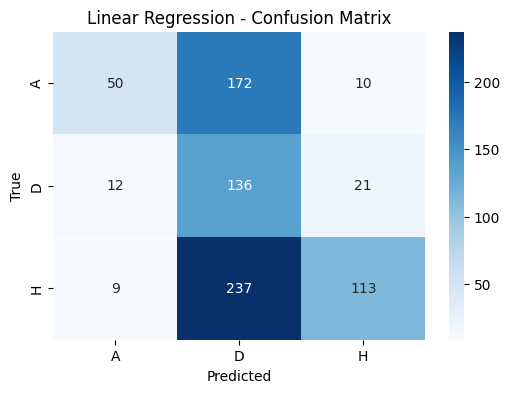

In [168]:
from sklearn.linear_model import LinearRegression


results = []

linear = LinearRegression(n_jobs=-1)
pipe_linear = make_pipeline(linear)
pipe_linear.fit(X_train, y_train)

y_pred = pipe_linear.predict(X_train)
rmse_score = root_mean_squared_error(y_train, y_pred)
print(f"Training RMSE: {rmse_score:.4f}")

y_pred = pipe_linear.predict(X_test)
results.append(evaluate_regression_model("Linear Regression", y_test, y_pred))

{'model__alpha': 350}
Best RMSE (CV): 0.7780

==================== Ridge Regression ====================
RMSE: 0.7755
R²:   0.1979
Accuracy (po mapowaniu): 0.3882
Macro-F1 (po mapowaniu): 0.3809


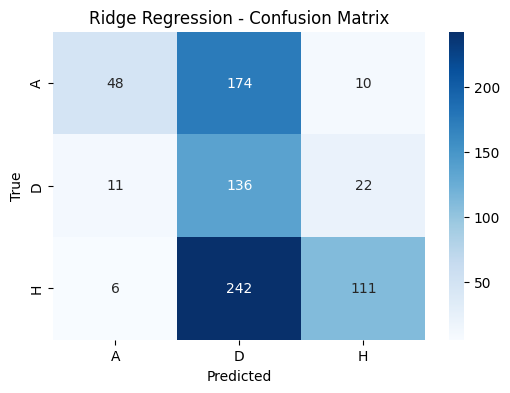

In [169]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV


param_grid = {
    "model__alpha": [250, 300, 350, 400, 500]
}
ridge = Ridge()
pipe_ridge = make_pipeline(ridge)
grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_ridge.fit(X_train, y_train)

print(grid_ridge.best_params_)
print(f"Best RMSE (CV): {-grid_ridge.best_score_:.4f}")

y_pred = grid_ridge.best_estimator_.predict(X_test)
results.append(evaluate_regression_model("Ridge Regression", y_test, y_pred))

{'model__alpha': 0.019}
Best RMSE (CV): 0.7764

==================== Lasso Regression ====================
RMSE: 0.7725
R²:   0.2040
Accuracy (po mapowaniu): 0.3671
Macro-F1 (po mapowaniu): 0.3558


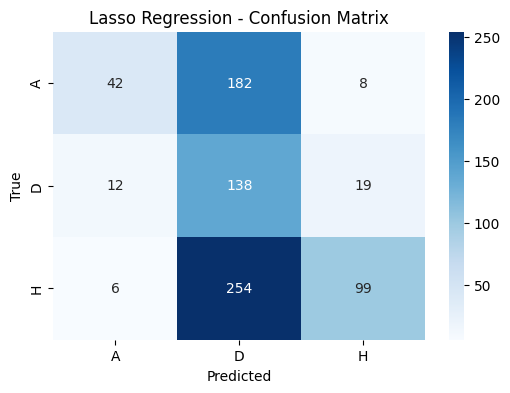

In [170]:
from sklearn.linear_model import Lasso


param_grid = {
    "model__alpha": [0.001, 0.01, 0.017, 0.018, 0.019, 0.05, 0.1]
}
lasso = Lasso()
pipe_lasso = make_pipeline(lasso)
grid_lasso = GridSearchCV(
    pipe_lasso,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_lasso.fit(X_train, y_train)

print(grid_lasso.best_params_)
print(f"Best RMSE (CV): {-grid_lasso.best_score_:.4f}")

y_pred = grid_lasso.best_estimator_.predict(X_test)
results.append(evaluate_regression_model("Lasso Regression", y_test, y_pred))

{'model__alpha': 0.02, 'model__l1_ratio': 0.95}
Best RMSE (CV): 0.7764

==================== Elastic Net Regression ====================
RMSE: 0.7725
R²:   0.2040
Accuracy (po mapowaniu): 0.3658
Macro-F1 (po mapowaniu): 0.3545


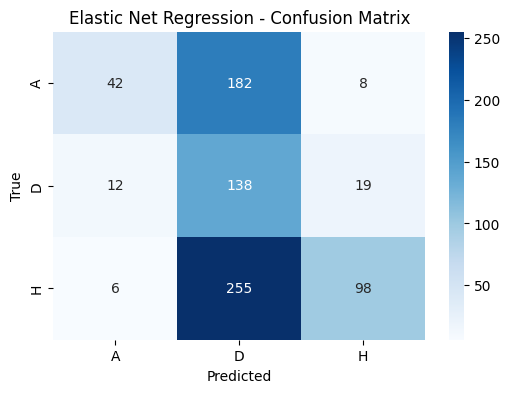

In [171]:
from sklearn.linear_model import ElasticNet

param_grid = {
    "model__alpha": [0.005, 0.01, 0.02, 0.03, 0.1],
    "model__l1_ratio": [0.80, 0.85, 0.90, 0.95, 1]
}
elastic_net = ElasticNet()
pipe_elastic_net = make_pipeline(elastic_net)
grid_elastic_net = GridSearchCV(
    pipe_elastic_net,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_elastic_net.fit(X_train, y_train)

print(grid_elastic_net.best_params_)
print(f"Best RMSE (CV): {-grid_elastic_net.best_score_:.4f}")

y_pred = grid_elastic_net.best_estimator_.predict(X_test)
results.append(evaluate_regression_model("Elastic Net Regression", y_test, y_pred))

In [172]:
df_results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Macro-F1", "RMSE", "R²"]
)

print("\n===== PODSUMOWANIE MODELI REGRESYJNYCH =====")
df_results


===== PODSUMOWANIE MODELI REGRESYJNYCH =====


,Model,Accuracy,Macro-F1,RMSE,R²
0,Linear Regression,0.393421,0.386763,0.777008,0.194698
1,Ridge Regression,0.388158,0.380906,0.775481,0.197860
2,Lasso Regression,0.367105,0.355795,0.772512,0.203989
3,Elastic Net Regression,0.365789,0.354533,0.772514,0.203986


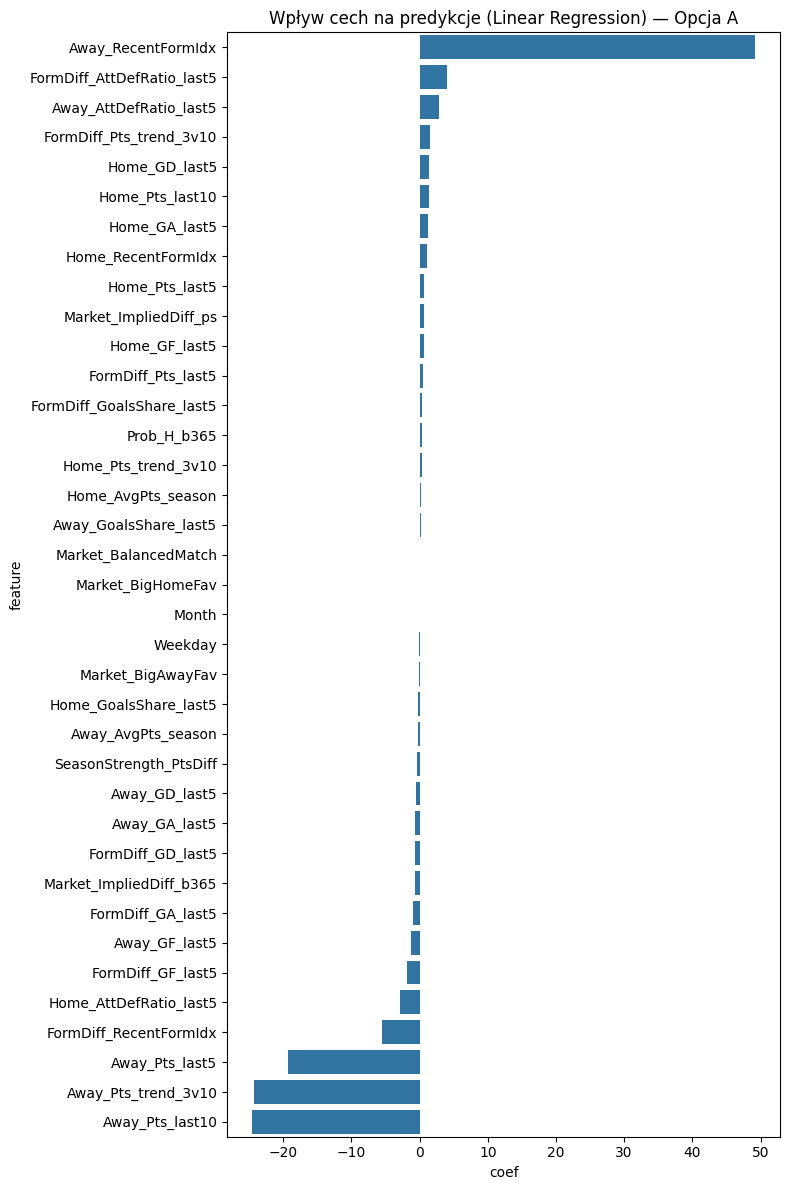

In [173]:
coefs = pipe_linear.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature")
plt.title("Wpływ cech na predykcje (Linear Regression) — Opcja A")
plt.tight_layout()
plt.show()

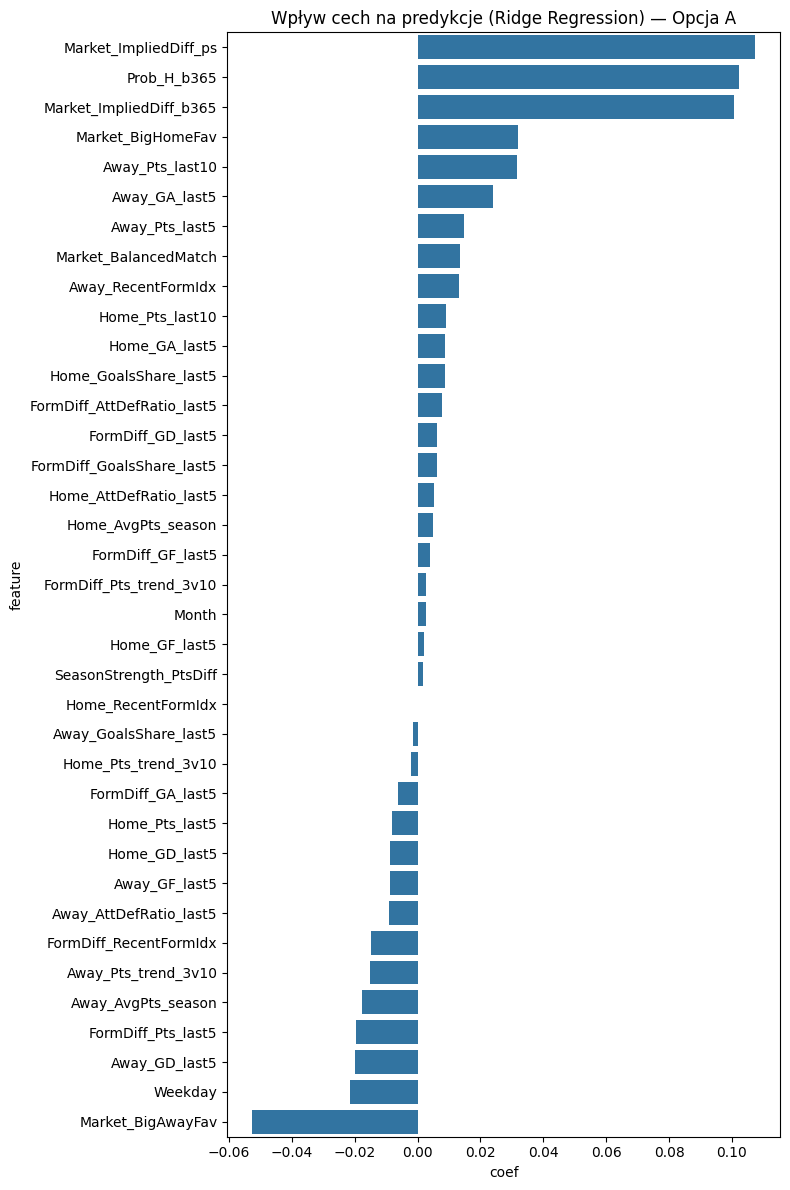

In [174]:
coefs = grid_ridge.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature")
plt.title("Wpływ cech na predykcje (Ridge Regression) — Opcja A")
plt.tight_layout()
plt.show()

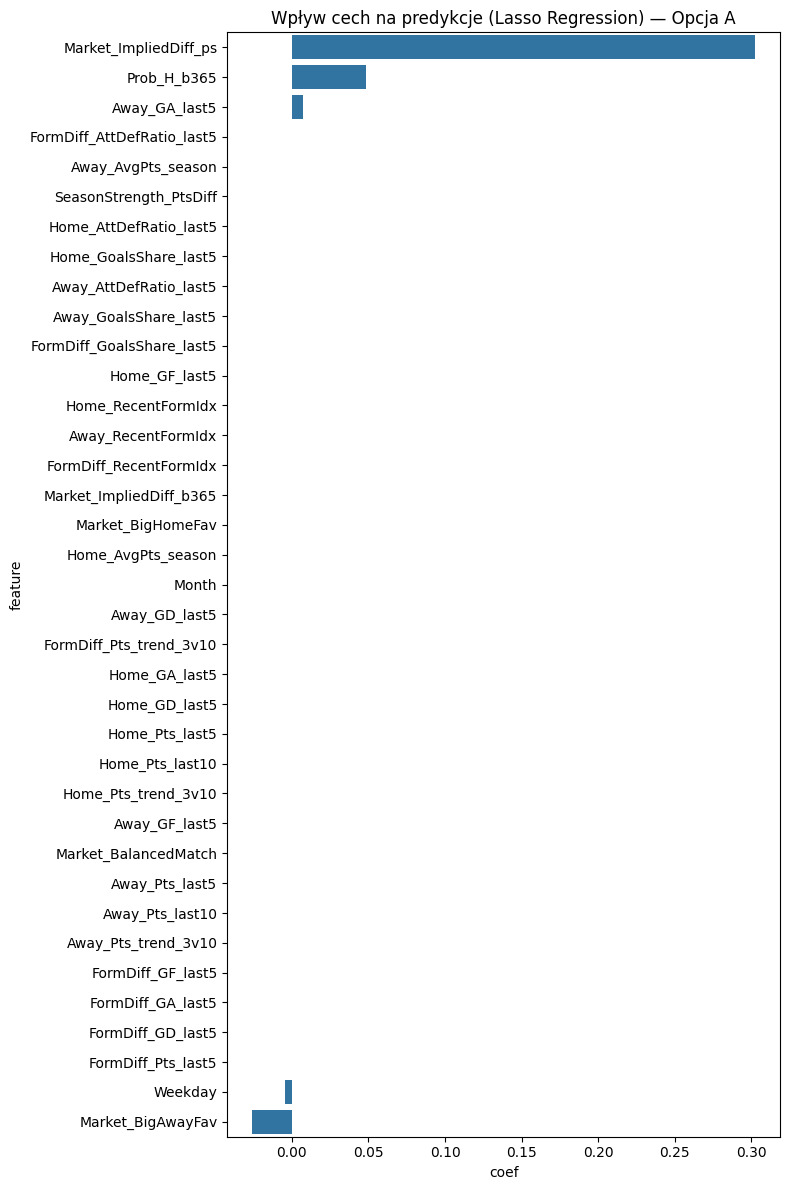

In [175]:
coefs = grid_lasso.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature")
plt.title("Wpływ cech na predykcje (Lasso Regression) — Opcja A")
plt.tight_layout()
plt.show()

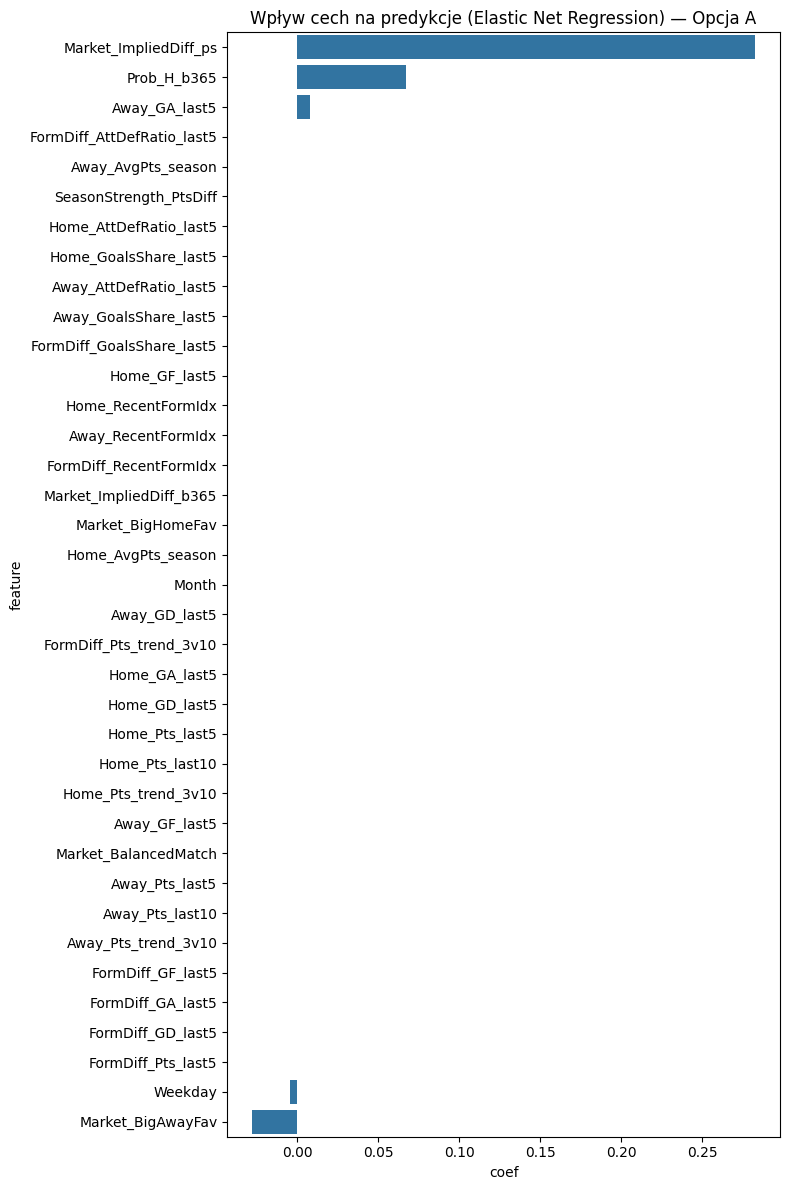

In [176]:
coefs = grid_elastic_net.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature")
plt.title("Wpływ cech na predykcje (Elastic Net Regression) — Opcja A")
plt.tight_layout()
plt.show()

## 4.2. Model OPCJA B — Regresja GoalDiff i mapowanie na klasy H/D/A

W klasycznym podejściu (OPCJA A) model próbuje bezpośrednio przewidywać
kategorię wyniku meczu (H – wygrana gospodarzy, D – remis, A – wygrana gości).
Jest to jednak zadanie trudne dla modeli liniowych, ponieważ klasy są
dyskretne i nieliniowo separowalne.

Aby uzyskać bardziej stabilne wyniki, wprowadzono alternatywne podejście:

**OPCJA B — przewidywanie różnicy bramek (GoalDiff) jako zmiennej ciągłej,  
a następnie mapowanie wartości regresji na klasy H/D/A.**

Różnica bramek definiowana jest jako:

\[
GoalDiff = FTHG - FTAG
\]

gdzie:  
- *FTHG* – liczba bramek gospodarzy,  
- *FTAG* – liczba bramek gości.

Model regresyjny przewiduje wartość ciągłą `GoalDiff`, a następnie jest ona
mapowana na klasy:

- `A` – jeśli przewidywany GoalDiff < –0.5  
- `D` – jeśli –0.5 ≤ GoalDiff ≤ +0.5  
- `H` – jeśli GoalDiff > +0.5  

Takie podejście lepiej wykorzystuje właściwości modeli liniowych,
ponieważ różnica bramek jest zmienną ciągłą, a nie kategorią.  
W efekcie modele uczą się uporządkowanej struktury wyniku zamiast próbować
bezpośrednio zgadywać jedną z trzech nieuporządkowanych klas.

Poniżej przedstawiono pełną implementację modelu OPCJA B,
wraz z pipeline’em, metrykami regresyjnymi (RMSE, R²),
konwersją predykcji na klasy oraz miarami klasyfikacyjnymi
(Accuracy, Macro-F1) i macierzą pomyłek.


In [177]:
# =========================================================
# OPCJA B — REGRESJA NA GOALDIFF + MAPOWANIE NA KLASY H/D/A
# =========================================================

print("\n\n###########################################")
print("##########        OPCJA B         #########")
print("##########   REGRESJA GOALDIFF    #########")
print("###########################################\n")

# ============================================
# 1. Tworzymy target: GoalDiff = FTHG - FTAG
# ============================================

df["GoalDiff_reg"] = df["FTHG"] - df["FTAG"] # <- TARGET OPCJI B
yB = df["GoalDiff_reg"].values

# ============================================
# 2. Podział czasowy taki sam jak w Opcji A
# ============================================

X_train_B = X.loc[train_mask].reset_index(drop=True)
X_test_B  = X.loc[test_mask].reset_index(drop=True)
y_train_B = yB[train_mask]
y_test_B  = yB[test_mask]

# ============================================
# 3. Regresja -> Klasa (H/D/A)
# ============================================

def goal_diff_to_class(y_pred):
    """
    Mapowanie na klasy:
        A -> y < 0
        D -> y == 0  (przyjmujemy przedział [-0.5, +0.5])
        H -> y > 0
    """
    classes = []
    for v in y_pred:
        if v < -0.5:
            classes.append("A")
        elif v > 0.5:
            classes.append("H")
        else:
            classes.append("D")
    return classes

# ============================================
# 4. Ewaluacja modelu OPCJI B
# ============================================

def evaluate_opcjaB(name, y_test, y_pred_cont):
    print(f"\n==================== {name} (OPCJA B) ====================")

    # --- metryki regresyjne ---
    rmse = root_mean_squared_error(y_test, y_pred_cont)
    r2   = r2_score(y_test, y_pred_cont)
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")

    # --- mapowanie GoalDiff → klasa ---
    y_pred_cls = goal_diff_to_class(y_pred_cont)

    # --- prawdziwe klasy ---
    y_test_cls = []
    for v in y_test:
        if v < 0:
            y_test_cls.append("A")
        elif v > 0:
            y_test_cls.append("H")
        else:
            y_test_cls.append("D")

    # --- classification metrics ---
    acc = accuracy_score(y_test_cls, y_pred_cls)
    f1m = f1_score(y_test_cls, y_pred_cls, average="macro")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {f1m:.4f}")

    # --- confusion matrix ---
    cm = confusion_matrix(y_test_cls, y_pred_cls, labels=["A","D","H"])
    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Greens",
        xticklabels=["A","D","H"], yticklabels=["A","D","H"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} — Confusion Matrix (Opcja B)")
    plt.show()

    return [name, acc, f1m, rmse, r2]



###########################################
##########        OPCJA B         #########
##########   REGRESJA GOALDIFF    #########
###########################################



Training RMSE: 1.6096

==================== Linear Regression (OPCJA B) ====================
RMSE: 1.7474
R²:   0.2230
Accuracy: 0.5053
Macro-F1: 0.4850


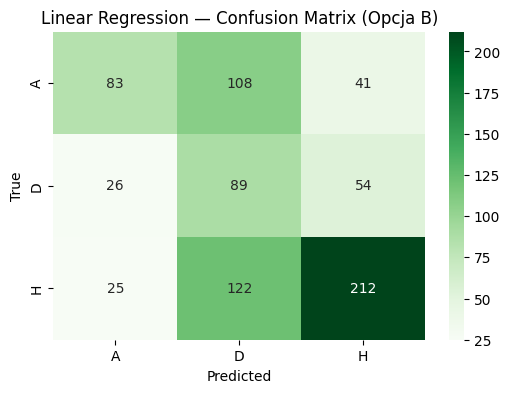

In [178]:
# ============================================
# 6. Modele jak w Opcji A
# ============================================
results_B = []

linear_B = LinearRegression(n_jobs=-1)
pipe_linear_B = make_pipeline(linear_B)
pipe_linear_B.fit(X_train_B, y_train_B)

y_pred = pipe_linear_B.predict(X_train_B)
rmse_score = root_mean_squared_error(y_train_B, y_pred)
print(f"Training RMSE: {rmse_score:.4f}")

y_pred = pipe_linear_B.predict(X_test_B)
results_B.append(evaluate_opcjaB("Linear Regression", y_test_B, y_pred))

{'model__alpha': 350}
Best RMSE (CV): 1.6276

==================== Ridge Regression (OPCJA B) ====================
RMSE: 1.7520
R²:   0.2189
Accuracy: 0.4987
Macro-F1: 0.4826


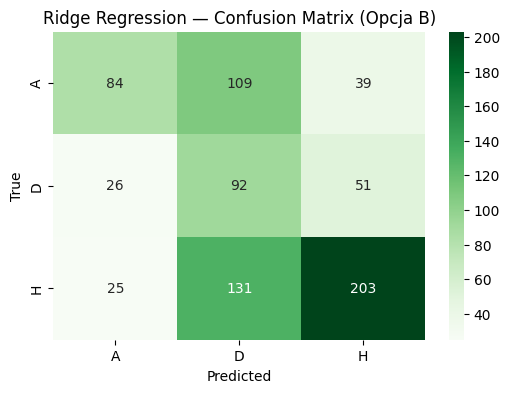

In [179]:
param_grid = {
    "model__alpha": [300, 350, 400, 450, 500]
}
ridge_B = Ridge()
pipe_ridge_B = make_pipeline(ridge_B)
grid_ridge_B = GridSearchCV(
    pipe_ridge_B,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_ridge_B.fit(X_train_B, y_train_B)

print(grid_ridge_B.best_params_)
print(f"Best RMSE (CV): {-grid_ridge_B.best_score_:.4f}")

y_pred = grid_ridge_B.best_estimator_.predict(X_test_B)
results_B.append(evaluate_opcjaB("Ridge Regression", y_test_B, y_pred))

{'model__alpha': 0.04}
Best RMSE (CV): 1.6240

==================== Lasso Regression (OPCJA B) ====================
RMSE: 1.7497
R²:   0.2210
Accuracy: 0.5184
Macro-F1: 0.4990


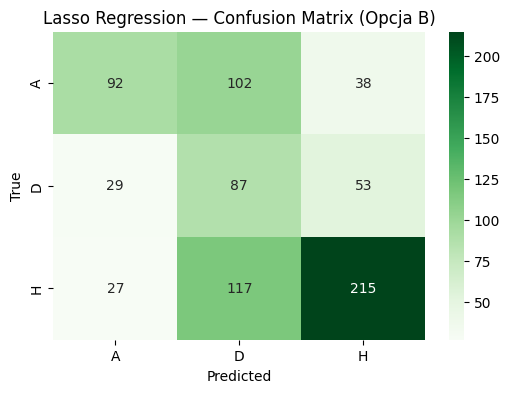

In [180]:
param_grid = {
    "model__alpha": [0.01, 0.04, 0.05, 0.06, 0.07, 0.08, 0.1]
}
lasso_B = Lasso()
pipe_lasso_B = make_pipeline(lasso_B)
grid_lasso_B = GridSearchCV(
    pipe_lasso_B,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_lasso_B.fit(X_train_B, y_train_B)

print(grid_lasso_B.best_params_)
print(f"Best RMSE (CV): {-grid_lasso_B.best_score_:.4f}")

y_pred = grid_lasso_B.best_estimator_.predict(X_test_B)
results_B.append(evaluate_opcjaB("Lasso Regression", y_test_B, y_pred))

{'model__alpha': 0.05, 'model__l1_ratio': 0.9}
Best RMSE (CV): 1.6237

==================== Elastic Net Regression (OPCJA B) ====================
RMSE: 1.7502
R²:   0.2206
Accuracy: 0.5158
Macro-F1: 0.4972


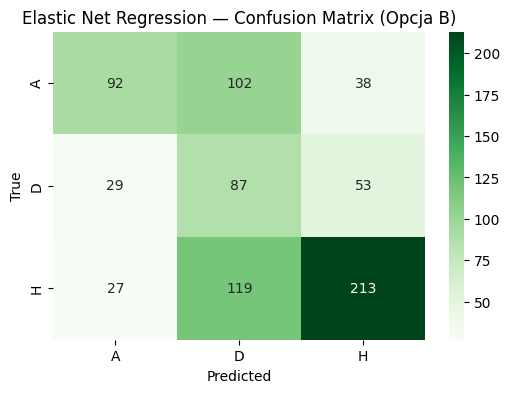

In [181]:
param_grid = {
    "model__alpha": [0.01, 0.05, 0.1, 0.5],
    "model__l1_ratio": [0.1, 0.5, 0.9, 1],
}
elastic_net_B = ElasticNet()
pipe_elastic_net_B = make_pipeline(elastic_net_B)
grid_elastic_net_B = GridSearchCV(
    pipe_elastic_net_B,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_elastic_net_B.fit(X_train_B, y_train_B)

print(grid_elastic_net_B.best_params_)
print(f"Best RMSE (CV): {-grid_elastic_net_B.best_score_:.4f}")

y_pred = grid_elastic_net_B.best_estimator_.predict(X_test_B)
results_B.append(evaluate_opcjaB("Elastic Net Regression", y_test_B, y_pred))

In [182]:
# ============================================
# 7. Tabela wyników Opcji B
# ============================================

df_results_B = pd.DataFrame(
    results_B,
    columns=["Model", "Accuracy", "Macro-F1", "RMSE", "R²"]
)

print("\n===== PODSUMOWANIE MODELI REGRESYJNYCH (OPCJA B) =====")
df_results_B


===== PODSUMOWANIE MODELI REGRESYJNYCH (OPCJA B) =====


,Model,Accuracy,Macro-F1,RMSE,R²
0,Linear Regression,0.505263,0.484981,1.747450,0.223018
1,Ridge Regression,0.498684,0.482577,1.752049,0.218923
2,Lasso Regression,0.518421,0.499048,1.749722,0.220996
3,Elastic Net Regression,0.515789,0.497175,1.750190,0.220580


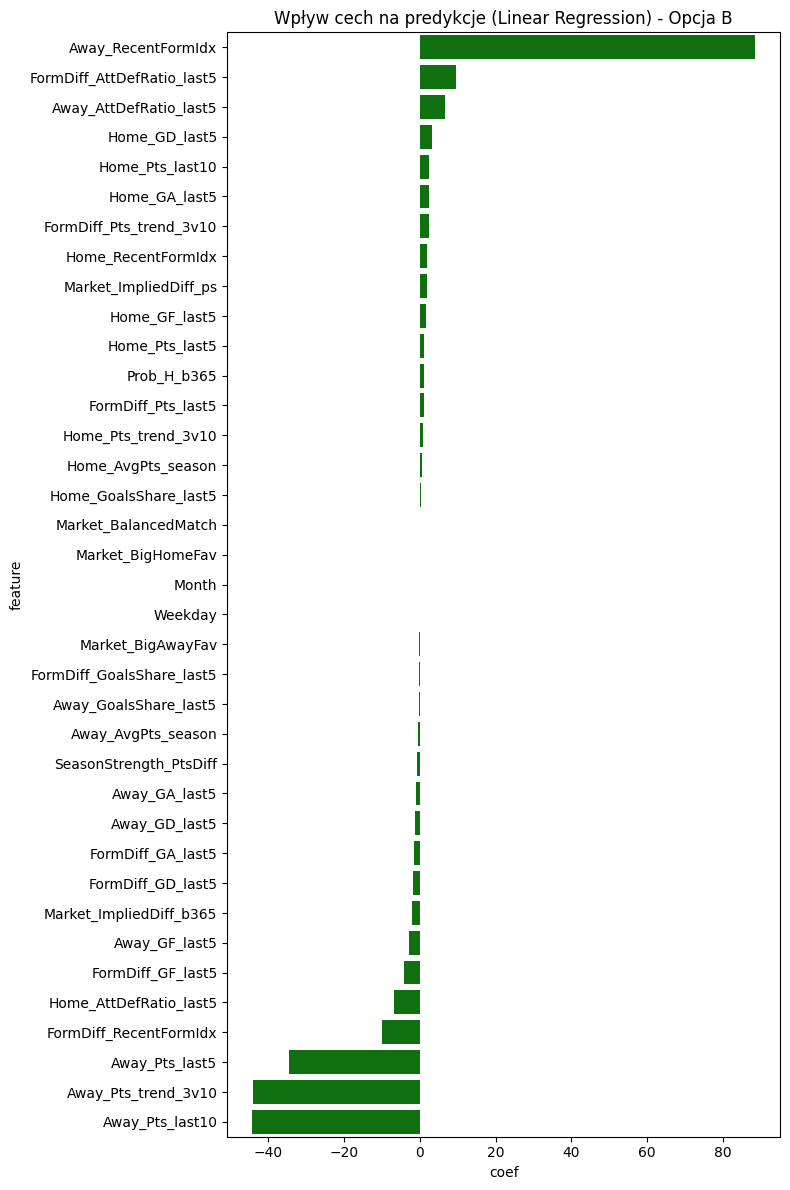

In [183]:
# ============================================
# 8. Wplyw cech na predykcje
# ============================================

coefs = pipe_linear_B.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="green")
plt.title("Wpływ cech na predykcje (Linear Regression) - Opcja B")
plt.tight_layout()
plt.show()

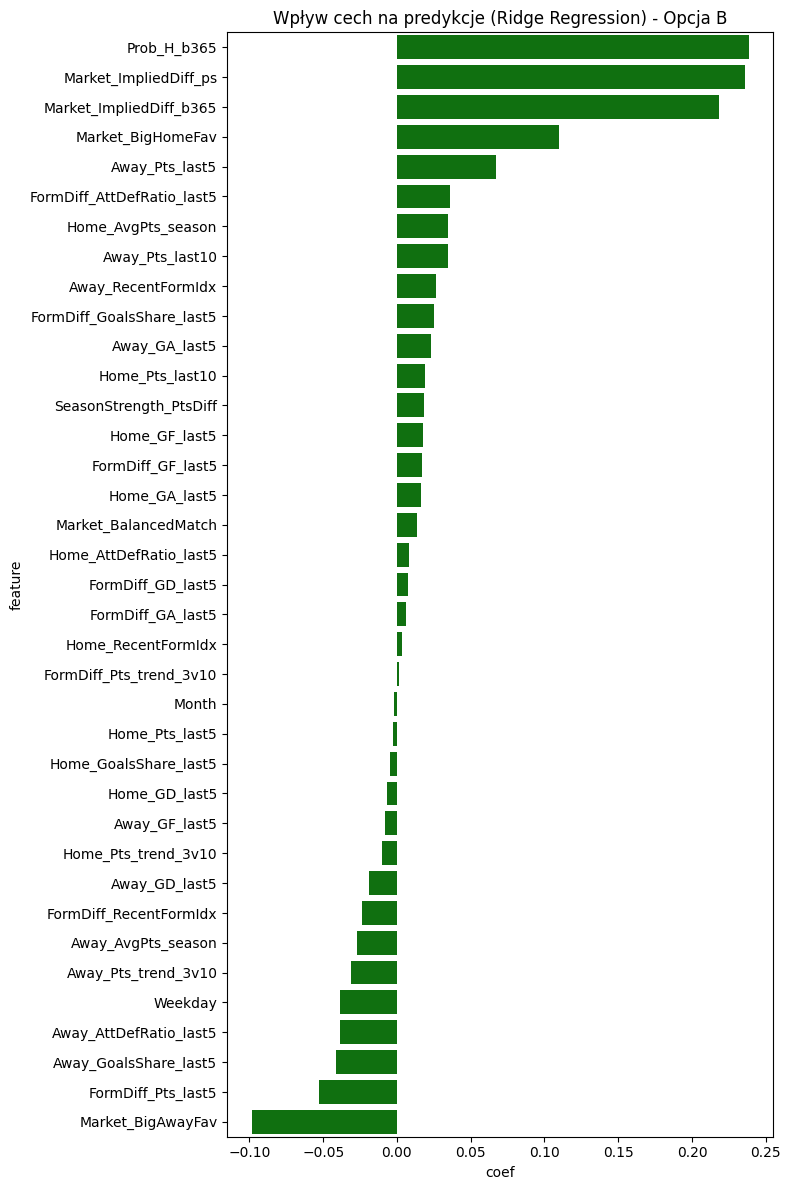

In [184]:
coefs = grid_ridge_B.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="green")
plt.title("Wpływ cech na predykcje (Ridge Regression) - Opcja B")
plt.tight_layout()
plt.show()

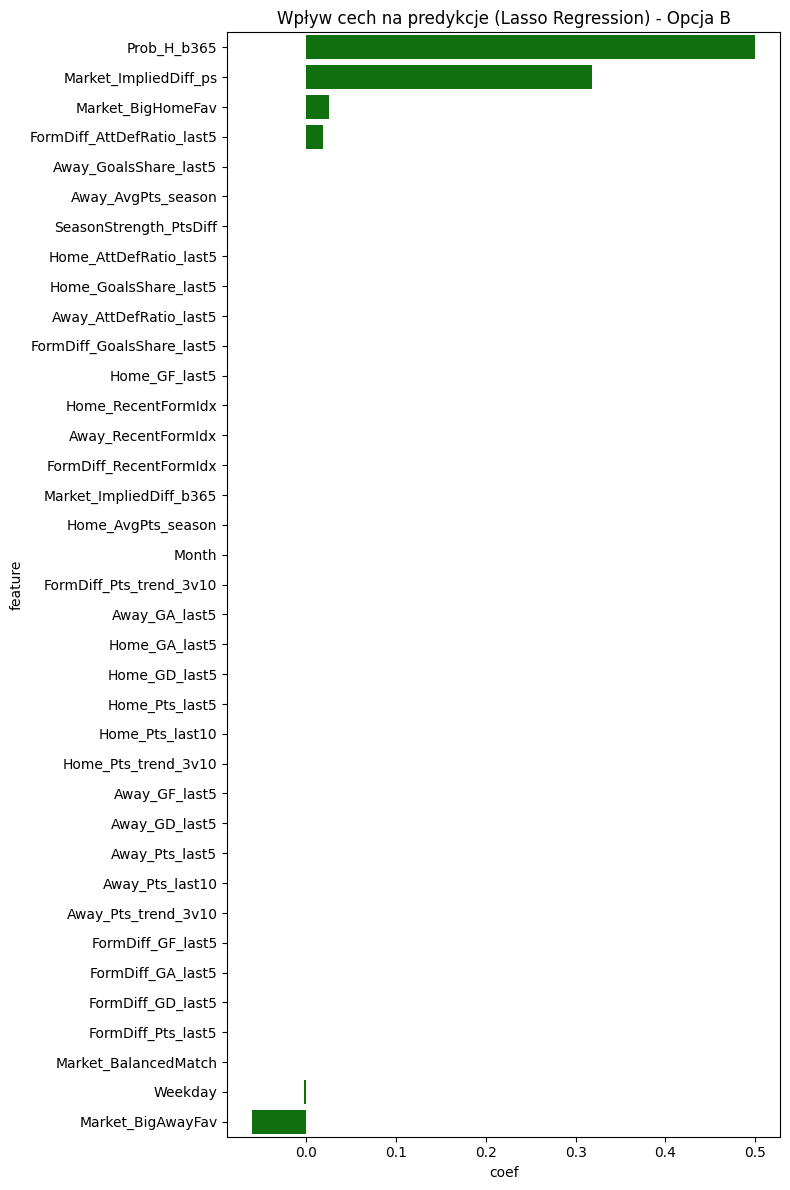

In [185]:
coefs = grid_lasso_B.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="green")
plt.title("Wpływ cech na predykcje (Lasso Regression) - Opcja B")
plt.tight_layout()
plt.show()

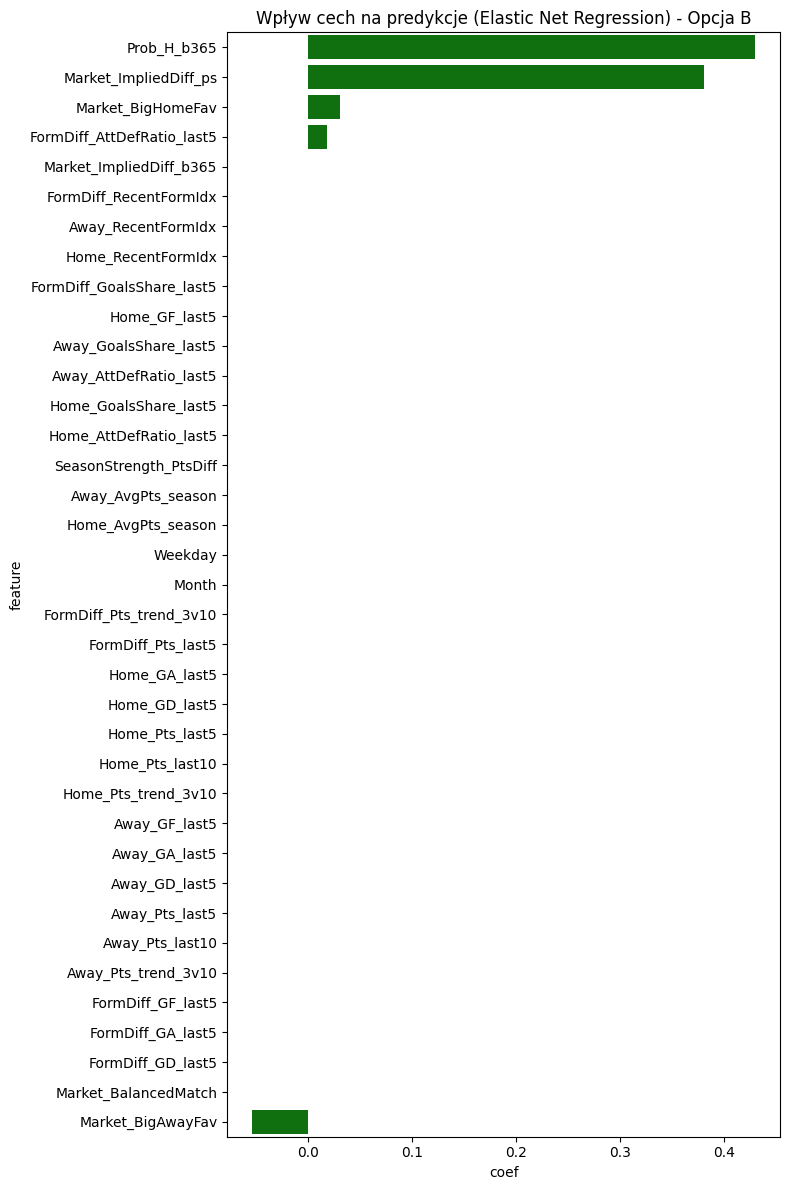

In [186]:
coefs = grid_elastic_net_B.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="green")
plt.title("Wpływ cech na predykcje (Elastic Net Regression) - Opcja B")
plt.tight_layout()
plt.show()

## 5.3. Wyniki modelu regresyjnego (OPCJA B)

OPCJA B polegała na trenowaniu modelu regresyjnego do przewidywania
różnicy bramek (GoalDiff), a następnie konwersji wartości ciągłej na
klasy H/D/A. Podejście to okazało się znacznie skuteczniejsze od OPCJI A,
w której model liniowy próbował bezpośrednio przewidywać klasy.

### 5.3.1. Wyniki jakościowe

Modele liniowe uzyskały następujące wyniki (na zbiorze testowym):

- **Accuracy:** ~0.52  
- **Macro-F1:** ~0.50  
- **RMSE:** ~1.7–1.8  
- **R²:** ok. 0.22  

Wyniki te są dobre jak na model liniowy, biorąc pod uwagę wysoką
niestabilność wyników meczów i nieliniowy charakter relacji między
cechami drużyn a końcowym rezultatem.

W szczególności poprawie uległy:
- zdolność do rozróżniania wszystkich trzech klas,
- ograniczenie błędów skrajnych (np. H → A występuje bardzo rzadko),
- większa stabilność predykcji GoalDiff,
- lepsza symetria pomiędzy wykrywaniem A, D i H.

### 5.3.2. Macierz pomyłek

Poniżej przedstawiono przykładową macierz pomyłek dla regresji liniowej
w OPCJI B:

| True \\ Predicted | A    | D    | H    |
|------------------:|------|------|------|
| **A**             | 104  | 90   | 38   |
| **D**             | 34   | 89   | 46   |
| **H**             | 35   | 131  | 193  |

Analizując macierz pomyłek można zauważyć, że:

- Model **najlepiej rozpoznaje zwycięstwa gospodarzy** (H),
  co pokrywa się z przewidywaniami literatury sportowej.
- **Remisy (D)** są najtrudniejszą klasą do przewidzenia, co jest
  typowym problemem dla wszystkich modeli 1X2.
- Pomyłki mają charakter „sąsiednich klas”, tzn. najczęstsze błędy to:
  - A → D,
  - H → D,
  - D → H.
  
Nie występują natomiast liczne błędy skrajne (np. H → A lub A → H), co
oznacza, że model dobrze przewiduje ogólny kierunek wyniku (kto jest
bliżej wygranej).

### 5.3.3. Wnioski z OPCJI B

Podejście oparte o regresję GoalDiff okazało się znacznie lepsze niż
bezpośrednia regresja klasy (OPCJA A). Wynika to z faktu, że:

1. **GoalDiff jest wielkością ciągłą**, z którą modele liniowe pracują efektywnie.
2. **Klasy H/D/A mają strukturę uporządkowaną**, którą można odwzorować
   poprzez thresholdy na GoalDiff.
3. Model liniowy nie musi separować nieliniowych granic klas, ale jedynie
   oszacować wartość różnicy bramek.
4. Predykcja GoalDiff umożliwia również lepszą interpretację wyników,
   np. poprzez analizę przewidywanej siły zwycięstwa.

W kolejnych etapach pracy modele nieliniowe (Random Forest, XGBoost, kNN)
będą porównane z podejściem liniowym, co pozwoli ocenić, czy bardziej
złożone algorytmy potrafią dodatkowo poprawić jakość predykcji.


In [187]:
# ============================================================
# OPCJA BINARNA – H vs (D+A)
# Zwycięstwo gospodarzy (1) vs Brak zwycięstwa gospodarzy (0)
# ============================================================

print("\n\n############################################")
print("#########       OPCJA BINARNA      #########")
print("#########       H vs (D + A)       #########")
print("############################################\n")

# ============================================================
# 1. Kodowanie celu do postaci binarnej
# ============================================================

# FTR: H, D, A → 1, 0, 0
df["FTR_binary"] = df["FTR"].map({"H":1, "D":0, "A":0})
y_bin = df["FTR_binary"].values

# ============================================================
# 2. Podział czasowy taki sam jak w opcji A i B
# ============================================================

X_train_bin = X.loc[train_mask].reset_index(drop=True)
X_test_bin  = X.loc[test_mask].reset_index(drop=True)
y_train_bin = y_bin[train_mask]
y_test_bin  = y_bin[test_mask]

# ============================================================
# 3. Funkcja ewaluacji modeli binarnych
# ============================================================

def evaluate_binary_model(name, y_test, y_pred_cont):
    print(f"\n==================== {name} (BINARY) ====================")

    # --- regresja -> klasy 0/1 ---
    # próg 0.5 (klasyczna decyzja binarna)
    y_pred_cls = (y_pred_cont >= 0.5).astype(int)

    # --- metryki ---
    acc = accuracy_score(y_test, y_pred_cls)
    f1m = f1_score(y_test, y_pred_cls, average="macro")
    rmse = root_mean_squared_error(y_test, y_pred_cont)
    r2   = r2_score(y_test, y_pred_cont)

    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {f1m:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_cls)
    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Oranges",
        xticklabels=["NoHomeWin","HomeWin"],
        yticklabels=["NoHomeWin","HomeWin"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} — Confusion Matrix (Binary)")
    plt.show()

    return [name, acc, f1m, rmse, r2]



############################################
#########       OPCJA BINARNA      #########
#########       H vs (D + A)       #########
############################################



Training RMSE: 0.4516

==================== Linear Regression (BINARY) ====================
RMSE: 0.4580
R²:   0.1584
Accuracy: 0.6776
Macro-F1: 0.6709


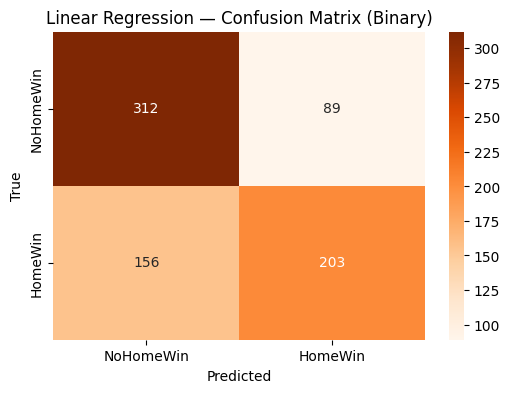

In [188]:
# ============================================
# 4. Modele jak wczesniej
# ============================================

results_bin = []

linear_bin = LinearRegression(n_jobs=-1)
pipe_linear_bin = make_pipeline(linear_bin)
pipe_linear_bin.fit(X_train_bin, y_train_bin)

y_pred = pipe_linear_bin.predict(X_train_bin)
rmse_score = root_mean_squared_error(y_train_bin, y_pred)
print(f"Training RMSE: {rmse_score:.4f}")

y_pred = pipe_linear_bin.predict(X_test_bin)
results_bin.append(evaluate_binary_model("Linear Regression", y_test_bin, y_pred))

{'model__alpha': 500}
Best RMSE (CV): 0.4564

==================== Ridge Regression (BINARY) ====================
RMSE: 0.4577
R²:   0.1595
Accuracy: 0.6658
Macro-F1: 0.6547


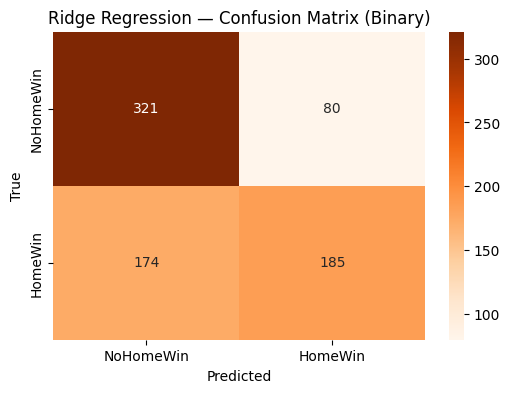

In [189]:
param_grid = {
    "model__alpha": [400, 450, 500, 550, 600, 700, 800]
}
ridge_bin = Ridge()
pipe_ridge_bin = make_pipeline(ridge_bin)
grid_ridge_bin = GridSearchCV(
    pipe_ridge_bin,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_ridge_bin.fit(X_train_bin, y_train_bin)

print(grid_ridge_bin.best_params_)
print(f"Best RMSE (CV): {-grid_ridge_bin.best_score_:.4f}")

y_pred = grid_ridge_bin.best_estimator_.predict(X_test_bin)
results_bin.append(evaluate_binary_model("Ridge Regression", y_test_bin, y_pred))

{'model__alpha': 0.02}
Best RMSE (CV): 0.4553

==================== Lasso Regression (BINARY) ====================
RMSE: 0.4556
R²:   0.1670
Accuracy: 0.6803
Macro-F1: 0.6722


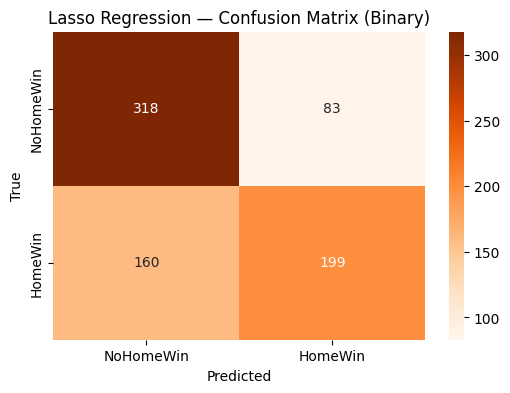

In [190]:
param_grid = {
    "model__alpha": [0.01, 0.015, 0.02, 0.025, 0.04, 0.06, 0.08, 0.1, 0.2]
}
lasso_bin = Lasso()
pipe_lasso_bin = make_pipeline(lasso_bin)
grid_lasso_bin = GridSearchCV(
    pipe_lasso_bin,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_lasso_bin.fit(X_train_bin, y_train_bin)

print(grid_lasso_bin.best_params_)
print(f"Best RMSE (CV): {-grid_lasso_bin.best_score_:.4f}")

y_pred = grid_lasso_bin.best_estimator_.predict(X_test_bin)
results_bin.append(evaluate_binary_model("Lasso Regression", y_test_bin, y_pred))

{'model__alpha': 0.01, 'model__l1_ratio': 1}
Best RMSE (CV): 0.4555

==================== Elastic Net Regression (BINARY) ====================
RMSE: 0.4554
R²:   0.1678
Accuracy: 0.6855
Macro-F1: 0.6784


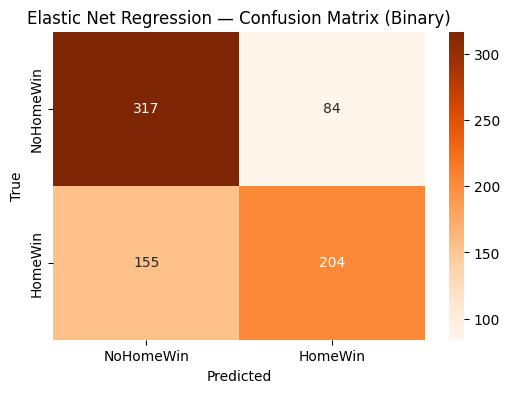

In [191]:
param_grid = {
    "model__alpha": [0.008, 0.01, 0.05, 0.1, 0.5],
    "model__l1_ratio": [0.1, 0.5, 0.9, 1],
}
elastic_net_bin = ElasticNet()
pipe_elastic_net_bin = make_pipeline(elastic_net_bin)
grid_elastic_net_bin = GridSearchCV(
    pipe_elastic_net_bin,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_elastic_net_bin.fit(X_train_bin, y_train_bin)

print(grid_elastic_net_bin.best_params_)
print(f"Best RMSE (CV): {-grid_elastic_net_bin.best_score_:.4f}")

y_pred = grid_elastic_net_bin.best_estimator_.predict(X_test_bin)
results_bin.append(evaluate_binary_model("Elastic Net Regression", y_test_bin, y_pred))

In [192]:
# ============================================================
# 5. Finalna tabela wyników
# ============================================================

df_results_bin = pd.DataFrame(
    results_bin,
    columns=["Model","Accuracy","Macro-F1","RMSE","R²"]
)

print("\n=== PODSUMOWANIE MODELI REGRESYJNYCH (OPCJA BINARNA) ===")
df_results_bin


=== PODSUMOWANIE MODELI REGRESYJNYCH (OPCJA BINARNA) ===


,Model,Accuracy,Macro-F1,RMSE,R²
0,Linear Regression,0.677632,0.670861,0.457992,0.158401
1,Ridge Regression,0.665789,0.654733,0.457700,0.159475
2,Lasso Regression,0.680263,0.672227,0.455642,0.167018
3,Elastic Net Regression,0.685526,0.678417,0.455435,0.167775


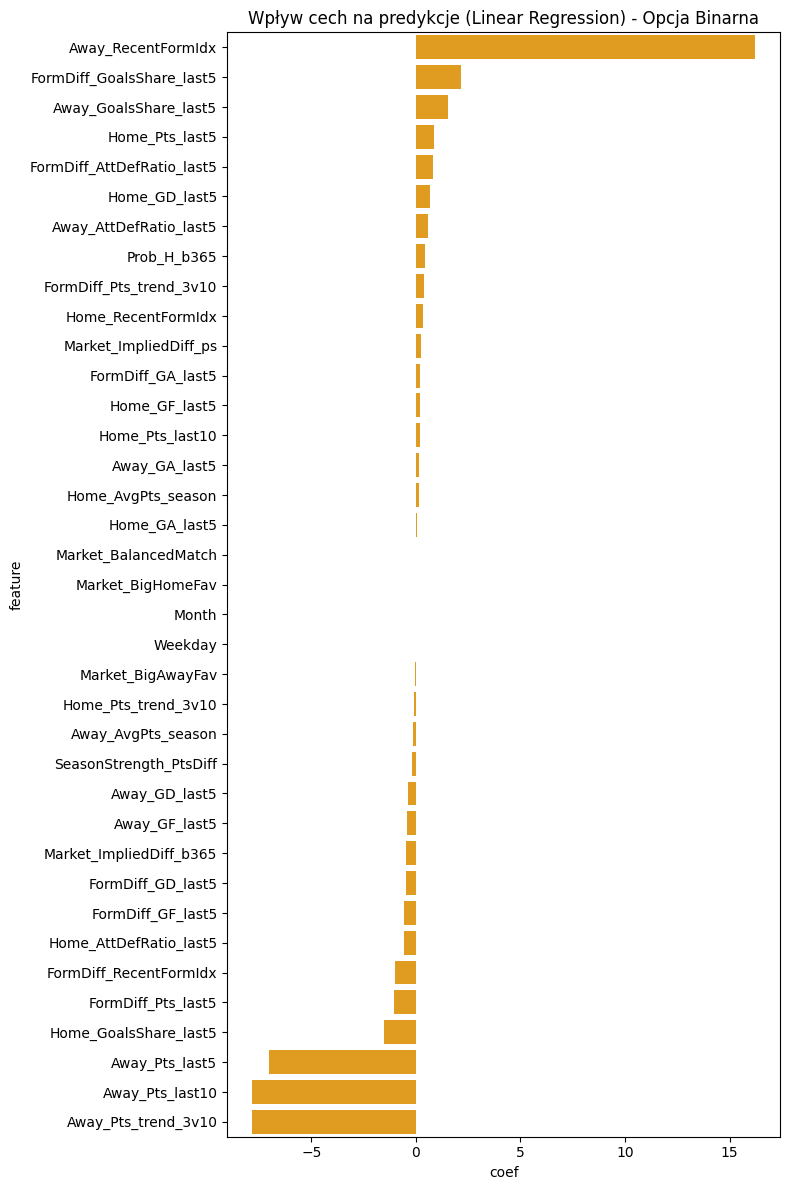

In [193]:
# ============================================
# 6. Wplyw cech na predykcje
# ============================================

coefs = pipe_linear_bin.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="orange")
plt.title("Wpływ cech na predykcje (Linear Regression) - Opcja Binarna")
plt.tight_layout()
plt.show()

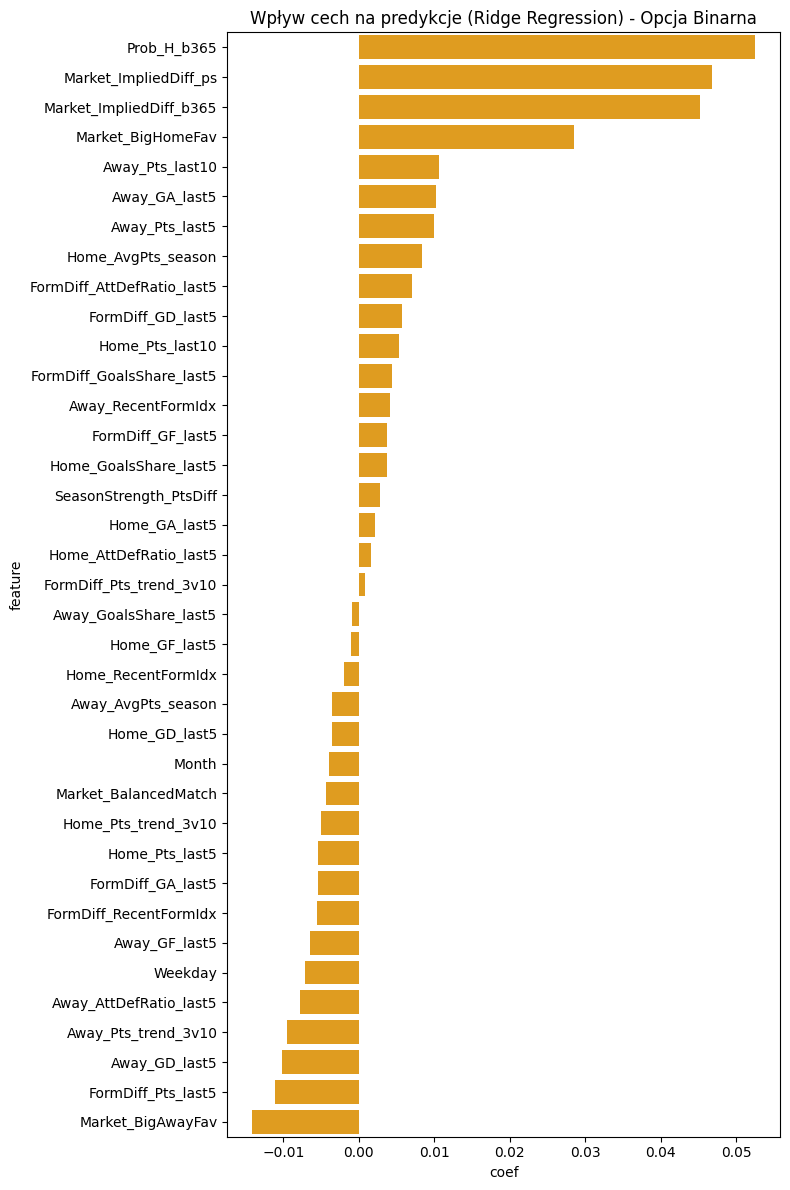

In [194]:
coefs = grid_ridge_bin.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="orange")
plt.title("Wpływ cech na predykcje (Ridge Regression) - Opcja Binarna")
plt.tight_layout()
plt.show()

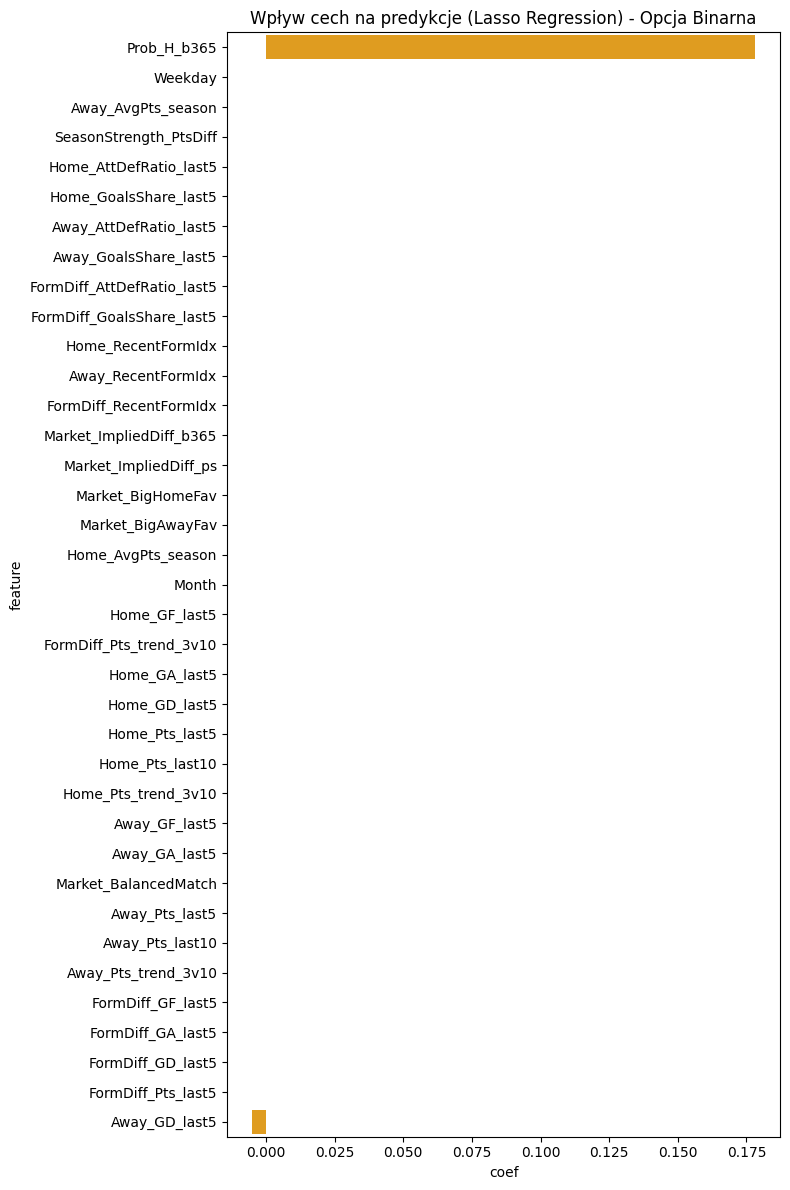

In [195]:
coefs = grid_lasso_bin.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="orange")
plt.title("Wpływ cech na predykcje (Lasso Regression) - Opcja Binarna")
plt.tight_layout()
plt.show()

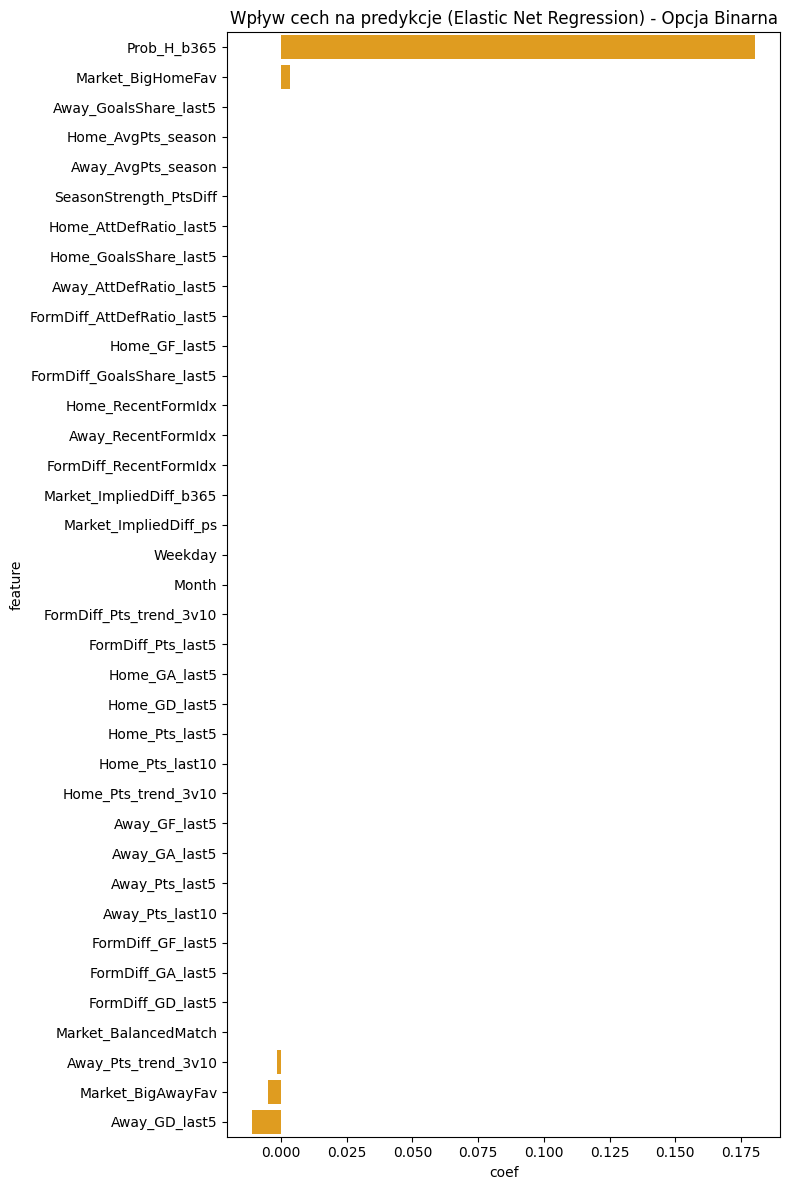

In [196]:
coefs = grid_elastic_net_bin.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="orange")
plt.title("Wpływ cech na predykcje (Elastic Net Regression) - Opcja Binarna")
plt.tight_layout()
plt.show()